In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

### Fetch The Data

In [2]:
from ucimlrepo import fetch_ucirepo

bank_marketing = fetch_ucirepo(id=222)

X = bank_marketing.data.features
y = bank_marketing.data.targets

print(bank_marketing.metadata)

print(bank_marketing.variables)

{'uci_id': 222, 'name': 'Bank Marketing', 'repository_url': 'https://archive.ics.uci.edu/dataset/222/bank+marketing', 'data_url': 'https://archive.ics.uci.edu/static/public/222/data.csv', 'abstract': 'The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit (variable y).', 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 45211, 'num_features': 16, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Occupation', 'Marital Status', 'Education Level'], 'target_col': ['y'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2014, 'last_updated': 'Fri Aug 18 2023', 'dataset_doi': '10.24432/C5K306', 'creators': ['S. Moro', 'P. Rita', 'P. Cortez'], 'intro_paper': {'ID': 277, 'type': 'NATIVE', 'title': 'A data-driven approach to predict the s

### Prepare The Data

In [3]:
import pandas as pd

# Create a df
df = pd.concat([X, y], axis=1)

# prevent data leakage and necessity to preprocess this irrelevant col
df = df.drop(columns='duration') 

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,1,-1,0,NaN,no


In [4]:
df.isna().sum() # check for na values

age                0
job              288
marital            0
education       1857
default            0
balance            0
housing            0
loan               0
contact        13020
day_of_week        0
month              0
campaign           0
pdays              0
previous           0
poutcome       36959
y                  0
dtype: int64

In [5]:
# Handle null values
# For categorical columns, nulls often indicate 'unknown' - preserve this information
df['job'] = df['job'].fillna('unknown')
df['education'] = df['education'].fillna('unknown')
df['contact'] = df['contact'].fillna('unknown')
df['poutcome'] = df['poutcome'].fillna('none')  # No previous campaign

# Verify no nulls remain
df.isna().sum()

age            0
job            0
marital        0
education      0
default        0
balance        0
housing        0
loan           0
contact        0
day_of_week    0
month          0
campaign       0
pdays          0
previous       0
poutcome       0
y              0
dtype: int64

In [6]:
# categorical
edu_map = {'unknown': 0, 'primary': 1, 'secondary': 2, 'tertiary': 3}
df['education'] = df['education'].map(edu_map)


# One Hot encoding
df = pd.get_dummies(df, columns=['job', 'marital', 'contact', 'poutcome', 'month'], drop_first=True)

# binary
binary_cols = ['default', 'housing', 'loan', 'y']
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

df.dtypes # print result

# Rest of the cols is of correct type

age                  int64
education            int64
default              int64
balance              int64
housing              int64
loan                 int64
day_of_week          int64
campaign             int64
pdays                int64
previous             int64
y                    int64
job_blue-collar       bool
job_entrepreneur      bool
job_housemaid         bool
job_management        bool
job_retired           bool
job_self-employed     bool
job_services          bool
job_student           bool
job_technician        bool
job_unemployed        bool
job_unknown           bool
marital_married       bool
marital_single        bool
contact_telephone     bool
contact_unknown       bool
poutcome_none         bool
poutcome_other        bool
poutcome_success      bool
month_aug             bool
month_dec             bool
month_feb             bool
month_jan             bool
month_jul             bool
month_jun             bool
month_mar             bool
month_may             bool
m

### Training

In [7]:
from perceptron import Perceptron
from trainer import Trainer

perceptron = Perceptron(2, 1)
trainer = Trainer(perceptron=perceptron, n_epochs=1000, learning_rate=0.01)
trainer1 = Trainer(perceptron=perceptron, n_epochs=1000, learning_rate=0.02)
trainer2 = Trainer(perceptron=perceptron, n_epochs=1000, learning_rate=0.1)
trainer3 = Trainer(perceptron=perceptron, n_epochs=10000, learning_rate=0.01)
trainer4 = Trainer(perceptron=perceptron, n_epochs=1000, learning_rate=0.001)

In [8]:
# Prepare data: extract age and balance features
x_features = df[['age', 'balance']].values  # shape: (samples, features)
y_target = df['y'].values  # shape: (samples,)

# Split into train/test sets
from sklearn.model_selection import train_test_split
x_train, X_test_val, y_train, y_test_val = train_test_split(
    x_features, y_target, test_size=0.3, random_state=42
)
x_val, x_test, y_val, y_test = train_test_split(X_test_val, y_test_val, test_size=0.5, random_state=42)

# Standardize features
mean = x_train.mean(axis=0, keepdims=True)
std  = x_train.std(axis=0, keepdims=True)

x_train = (x_train - mean) / (std + 1e-8)
x_val   = (x_val   - mean) / (std + 1e-8)  
x_test  = (x_test  - mean) / (std + 1e-8)

# Transpose to match perceptron format: (features, samples)
x_train_t = x_train.T
x_val_t = x_val.T
x_test_t = x_test.T

print(f"Training set: {x_train_t.shape[1]} samples, {x_train_t.shape[0]} features")
print(f"Test set: {x_test_t.shape[1]} samples")
print(f"Class distribution in training: {y_train.sum()} positive, {len(y_train) - y_train.sum()} negative")

Training set: 31647 samples, 2 features
Test set: 6782 samples
Class distribution in training: 3691 positive, 27956 negative


Testing trainer with params 
lr: 0.01 
epochs: 1000 
Epoch 0: Loss 1.1967, F1 Score: 0.2089
Epoch 100: Loss 0.8885, F1 Score: 0.2089
Epoch 200: Loss 0.6958, F1 Score: 0.2118
Epoch 300: Loss 0.5786, F1 Score: 0.0043
Epoch 400: Loss 0.5065, F1 Score: 0.0022
Epoch 500: Loss 0.4610, F1 Score: 0.0016
Epoch 600: Loss 0.4312, F1 Score: 0.0011
Epoch 700: Loss 0.4112, F1 Score: 0.0011
Epoch 800: Loss 0.3974, F1 Score: 0.0011
Epoch 900: Loss 0.3876, F1 Score: 0.0011

Final Test F1 Score: 0.00%
Predictions shape: (1, 6782)
Sample predictions: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]


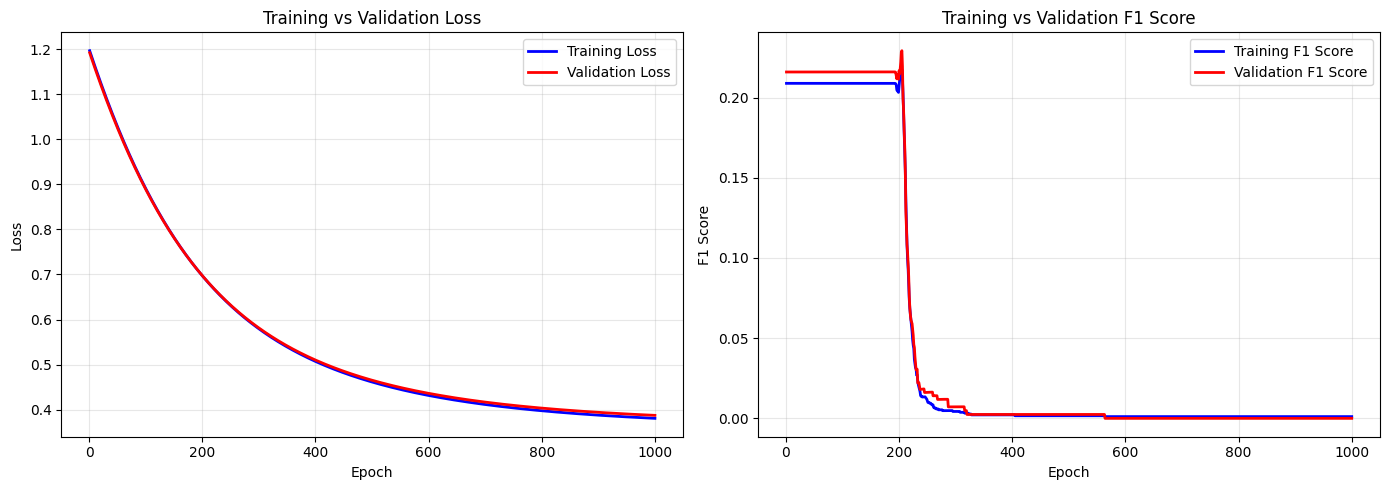

Testing trainer with params 
lr: 0.02 
epochs: 1000 
Epoch 0: Loss 0.3806, F1 Score: 0.0011
Epoch 100: Loss 0.3716, F1 Score: 0.0011
Epoch 200: Loss 0.3666, F1 Score: 0.0011
Epoch 300: Loss 0.3636, F1 Score: 0.0011
Epoch 400: Loss 0.3618, F1 Score: 0.0011
Epoch 500: Loss 0.3607, F1 Score: 0.0011
Epoch 600: Loss 0.3600, F1 Score: 0.0011
Epoch 700: Loss 0.3596, F1 Score: 0.0011
Epoch 800: Loss 0.3593, F1 Score: 0.0011
Epoch 900: Loss 0.3591, F1 Score: 0.0016

Final Test F1 Score: 0.00%
Predictions shape: (1, 6782)
Sample predictions: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]


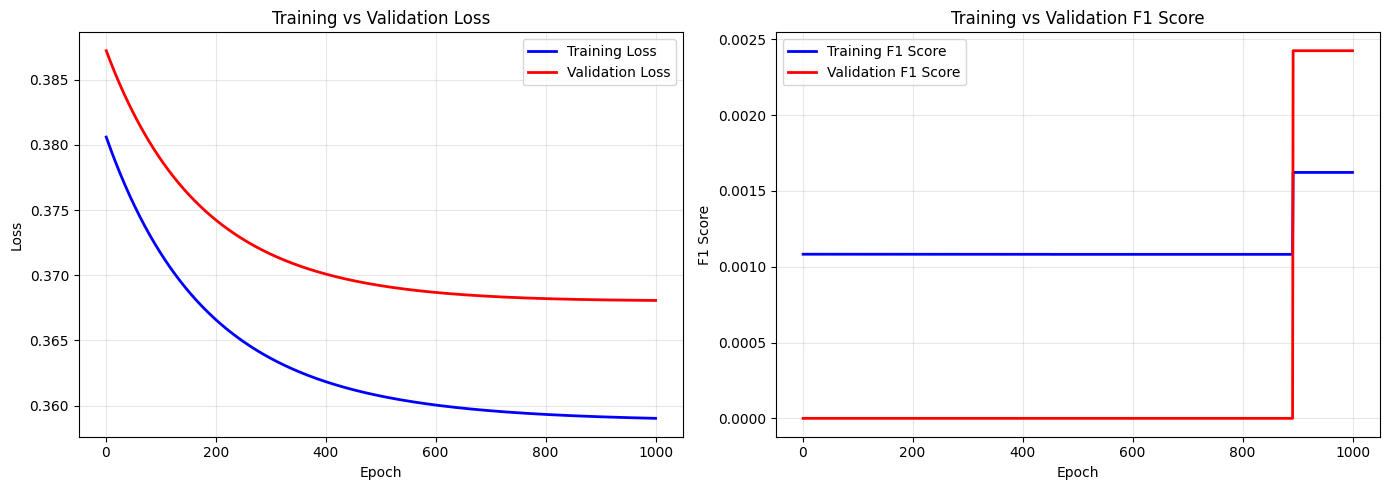

Testing trainer with params 
lr: 0.1 
epochs: 1000 
Epoch 0: Loss 0.3590, F1 Score: 0.0016
Epoch 100: Loss 0.3588, F1 Score: 0.0016
Epoch 200: Loss 0.3588, F1 Score: 0.0016
Epoch 300: Loss 0.3588, F1 Score: 0.0016
Epoch 400: Loss 0.3588, F1 Score: 0.0016
Epoch 500: Loss 0.3588, F1 Score: 0.0016
Epoch 600: Loss 0.3588, F1 Score: 0.0016
Epoch 700: Loss 0.3588, F1 Score: 0.0016
Epoch 800: Loss 0.3588, F1 Score: 0.0016
Epoch 900: Loss 0.3588, F1 Score: 0.0016

Final Test F1 Score: 0.00%
Predictions shape: (1, 6782)
Sample predictions: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]


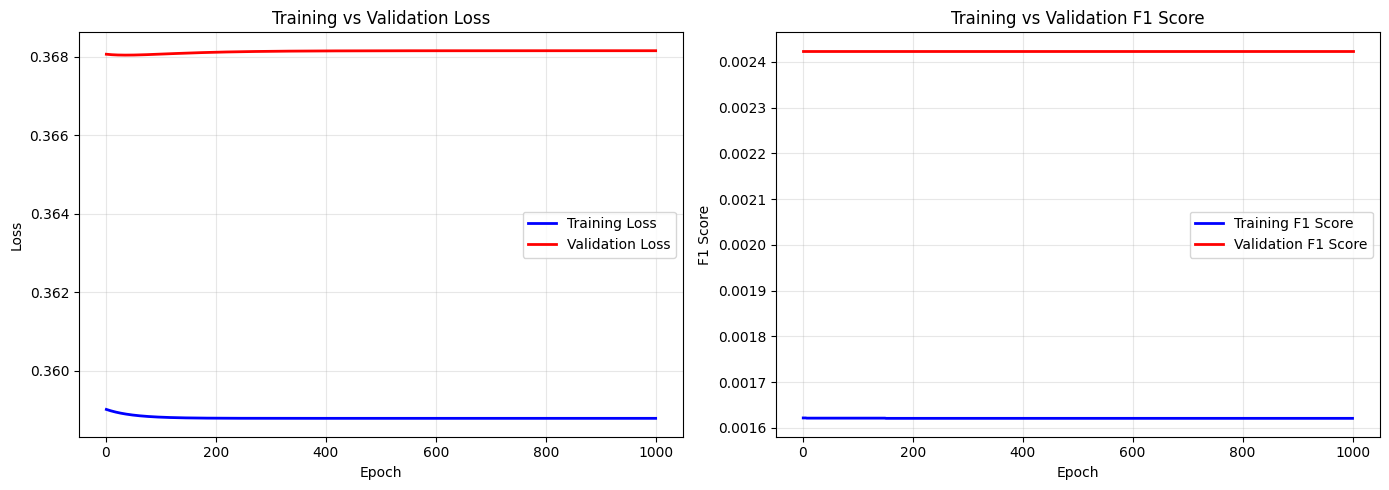

Testing trainer with params 
lr: 0.01 
epochs: 10000 
Epoch 0: Loss 0.3588, F1 Score: 0.0016
Epoch 100: Loss 0.3588, F1 Score: 0.0016
Epoch 200: Loss 0.3588, F1 Score: 0.0016
Epoch 300: Loss 0.3588, F1 Score: 0.0016
Epoch 400: Loss 0.3588, F1 Score: 0.0016
Epoch 500: Loss 0.3588, F1 Score: 0.0016
Epoch 600: Loss 0.3588, F1 Score: 0.0016
Epoch 700: Loss 0.3588, F1 Score: 0.0016
Epoch 800: Loss 0.3588, F1 Score: 0.0016
Epoch 900: Loss 0.3588, F1 Score: 0.0016
Epoch 1000: Loss 0.3588, F1 Score: 0.0016
Epoch 1100: Loss 0.3588, F1 Score: 0.0016
Epoch 1200: Loss 0.3588, F1 Score: 0.0016
Epoch 1300: Loss 0.3588, F1 Score: 0.0016
Epoch 1400: Loss 0.3588, F1 Score: 0.0016
Epoch 1500: Loss 0.3588, F1 Score: 0.0016
Epoch 1600: Loss 0.3588, F1 Score: 0.0016
Epoch 1700: Loss 0.3588, F1 Score: 0.0016
Epoch 1800: Loss 0.3588, F1 Score: 0.0016
Epoch 1900: Loss 0.3588, F1 Score: 0.0016
Epoch 2000: Loss 0.3588, F1 Score: 0.0016
Epoch 2100: Loss 0.3588, F1 Score: 0.0016
Epoch 2200: Loss 0.3588, F1 Score:

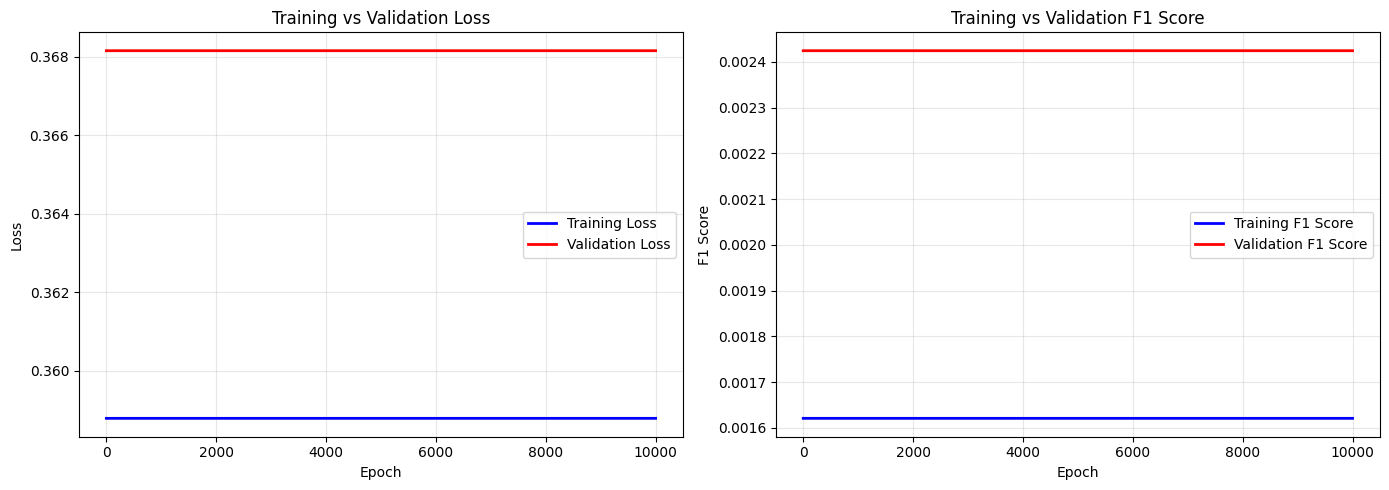

Testing trainer with params 
lr: 0.001 
epochs: 1000 
Epoch 0: Loss 0.3588, F1 Score: 0.0016
Epoch 100: Loss 0.3588, F1 Score: 0.0016
Epoch 200: Loss 0.3588, F1 Score: 0.0016
Epoch 300: Loss 0.3588, F1 Score: 0.0016
Epoch 400: Loss 0.3588, F1 Score: 0.0016
Epoch 500: Loss 0.3588, F1 Score: 0.0016
Epoch 600: Loss 0.3588, F1 Score: 0.0016
Epoch 700: Loss 0.3588, F1 Score: 0.0016
Epoch 800: Loss 0.3588, F1 Score: 0.0016
Epoch 900: Loss 0.3588, F1 Score: 0.0016

Final Test F1 Score: 0.00%
Predictions shape: (1, 6782)
Sample predictions: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]


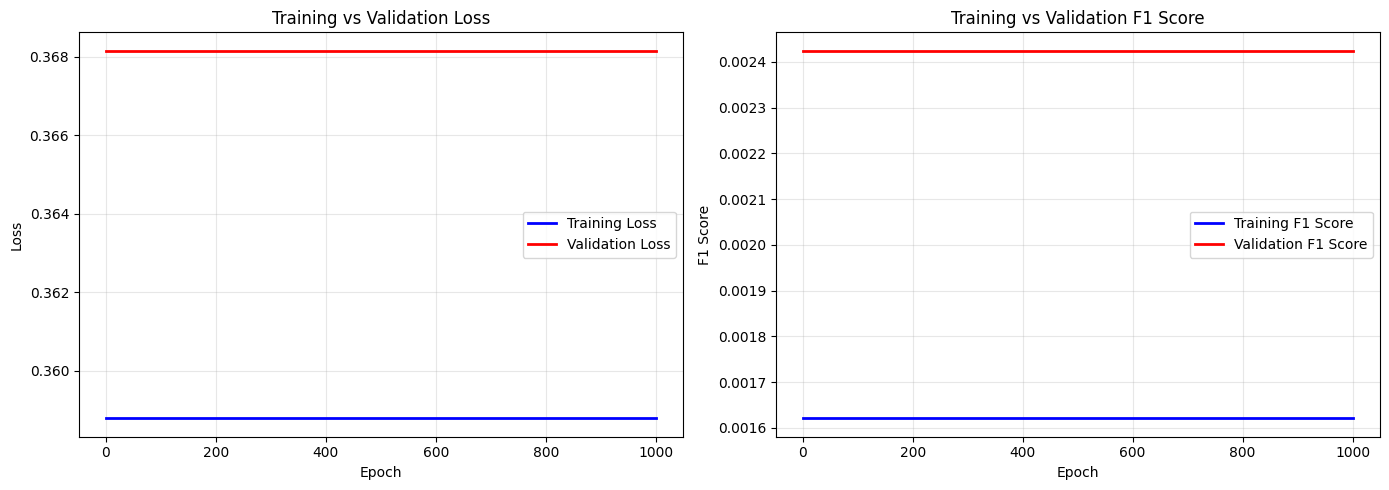

In [9]:
from util import test_trainers

# trainers to test
trainers = [trainer, trainer1, trainer2, trainer3, trainer4]

# test all the trainers
test_trainers(trainers=trainers, x_train=x_train_t, y_train=y_train, x_val=x_val_t, y_val=y_val, x_test=x_test_t, y_test=y_test)

### Perceptron in Torch

Epoch 0: Train Loss = 0.5548, Train F1 = 0.1753
Epoch 100: Train Loss = 0.5469, Train F1 = 0.1749
Epoch 200: Train Loss = 0.5394, Train F1 = 0.1747
Epoch 300: Train Loss = 0.5322, Train F1 = 0.1747
Epoch 400: Train Loss = 0.5253, Train F1 = 0.1722
Epoch 500: Train Loss = 0.5188, Train F1 = 0.1693
Epoch 600: Train Loss = 0.5125, Train F1 = 0.1688
Epoch 700: Train Loss = 0.5065, Train F1 = 0.1652
Epoch 800: Train Loss = 0.5008, Train F1 = 0.1658
Epoch 900: Train Loss = 0.4953, Train F1 = 0.1634

Final Train F1 Score: 0.1626
Final Val F1 Score: 0.1629


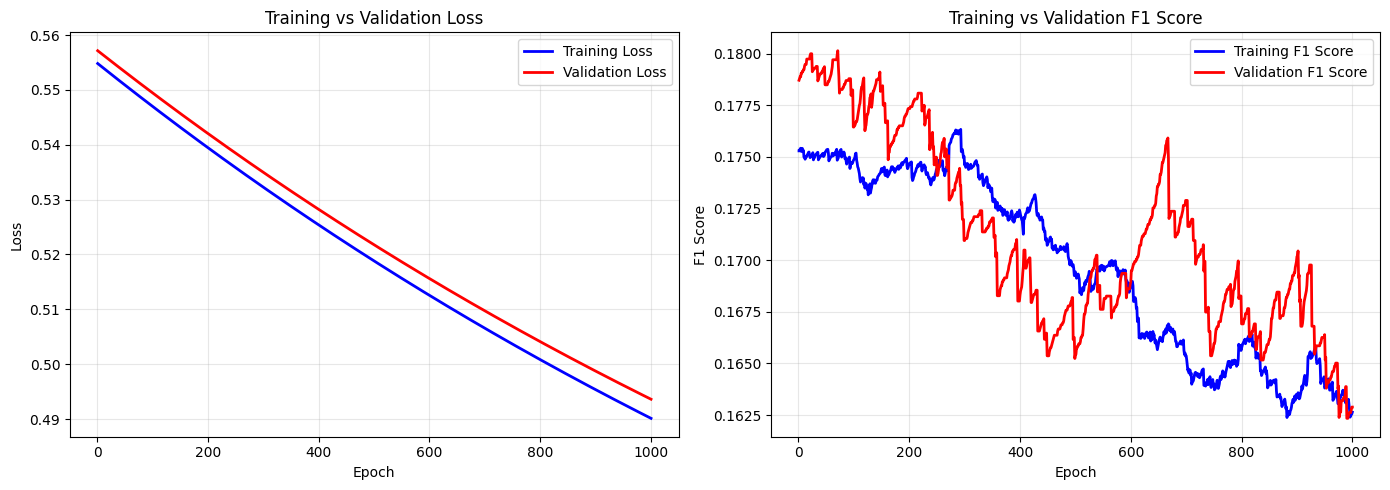

In [10]:
from perceptron_nn import Perceptron

perceptron_nn = Perceptron(x_train=x_train, y_train=y_train, x_val=x_val, y_val = y_val)

# Perform the training
perceptron_nn.train()

# Visualize the training loss and accuracy
perceptron_nn.plot_metrics()

### Analysis of the results

We have been training 5 different perceptron models, teaching it how 2 variables - age, balance influence our 'y' target variable.

2 variables to train a model on is quite few, compared to how many others are accessible in the dataset, however I still believe were we to train a perfect model on just these two, it's f1 would be higher than random guessing. So I believe there is some correlation to be found here. Enough about beliefs. Let's get to the data.

### Epochs: 1000

#### lr: 0.01

highest f1 was achieved of 0.2118 around epoch 200, probably slightly more than that since not all the scores were logged. After that f1 score started to decrease, so I would say the model was overtrained if not for the constant decrease in the loss up until it's final epoch.

#### lr: 0.02

the results are plain weird in terms of f1 - loss decrease way okay. The f1 stagnated for ~900 epochs and then bumped up.

#### lr: 0.1

4 straight lines, where loss makes sense because training one is lower, but why is validation f1 higher than the training one?

#### lr: 0.001

these charts look very much so like the ones above. I think the answer is to the above is to be found here.

#### nn, lr: 0.001

here we should expect to see the similar chart to the one above, since the params are the same. Except they aren't, nn module uses an optimizer and the loss is the best of all, f1 looks the most interesting of all. It didn't achieve the highest score because f1 kept going down overall. I don't know how it can be such that we are making the model worse than random guessing. The mistake is definitely in the training phase then


#### Best

f1: my impl, lr 0.01
loss: nn
most interesting: nn